In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm

In [3]:
import mpmath as mp
mp.mp.dps = 50

In [4]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)

In [17]:
def stochastic_gradient_sqW2loss_gaussian(theta, gen_sample, target_sample):
    N = len(gen_sample)
    target_sample_sorted = np.sort(target_sample)
    gen_sample_sorted = np.sort(gen_sample)
    grad_mu = 2 * np.mean(gen_sample_sorted - target_sample_sorted)
    z = (gen_sample_sorted - theta[0]) / theta[1]
    grad_sigma = 2 * np.mean((gen_sample_sorted - target_sample_sorted) * z)
    return np.array([grad_mu, grad_sigma])

def robbins_monro_steps(i, eta0, gamma):
    return eta0 / (1 + gamma*float(i))

def sgd_empirical_sqW2loss_gaussian(theta0, true_theta, sample_size, n_iter, eta0, gamma):
    theta = np.array(theta0)
    theta_trj = []
    theta_trj.append(np.array(theta))
    for i in range(n_iter):
        # Target sample
        target_sample = np.random.normal(true_theta[0], true_theta[1], sample_size)
        # Generator sample with current theta
        gen_sample = np.random.normal(theta[0], theta[1], sample_size)
        grad = stochastic_gradient_sqW2loss_gaussian(theta, gen_sample, target_sample)
        stepsize = robbins_monro_steps(i, eta0, gamma)
        theta -= stepsize * grad
        # print(grad, theta)
        theta_trj.append(np.array(theta))
    theta_trj = np.array(theta_trj)
    return theta_trj


In [67]:
np.random.seed(0)
true_theta = np.array([0., 1.])
theta0 = np.array([1., 2.])
n_iter, eta0, gamma = 10000, 0.01, 0.01
sample_size_set = [2, 5, 10, 20, 50, 100]

theta_trj_set = {}
theta_emp_sol_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_trj = sgd_empirical_sqW2loss_gaussian(theta0, true_theta, sample_size, n_iter, eta0, gamma)
    theta_emp_sol = analytic_sol_gaussian(true_theta[0], true_theta[1], sample_size)
    theta_trj_set[str(sample_size)] = theta_trj
    theta_emp_sol_set[str(sample_size)] = theta_emp_sol

0 2
1 5
2 10
3 20
4 50
5 100


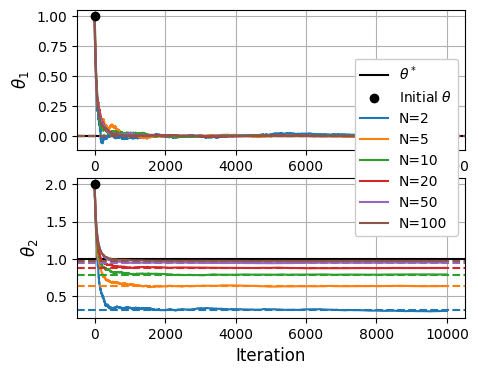

In [76]:
plt.figure(figsize=(5,4))
for i in range(2):
    plt.subplot(2,1,i+1)
    plt.axhline(true_theta[i], color='k', linestyle='-', label=fr'$\theta^*$')
    plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
    for j, sample_size in enumerate(sample_size_set):
        theta_trj = theta_trj_set[str(sample_size)]
        theta_emp_sol = theta_emp_sol_set[str(sample_size)]
        plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
        plt.axhline(theta_emp_sol[i], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
    plt.grid()
    
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel(fr'$\theta_{i+1}$', fontsize=12)
    if i == 1:
        plt.legend(loc='upper right', framealpha=1.0, bbox_to_anchor=(1.0, 1.9))
# plt.savefig(f'./fig_sgd_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)